In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
## noul modul importat
import matplotlib.animation as animation

In [5]:
df = pd.read_csv("countries.csv", index_col="index")
df

,tara,populatie
index,,
8,Bangladesh,170
6,Brazil,213
1,China,1411
2,India,1378
4,Indonesia,271
10,Mexico,126
7,Nigeria,211
5,Pakistan,225
9,Russia,146


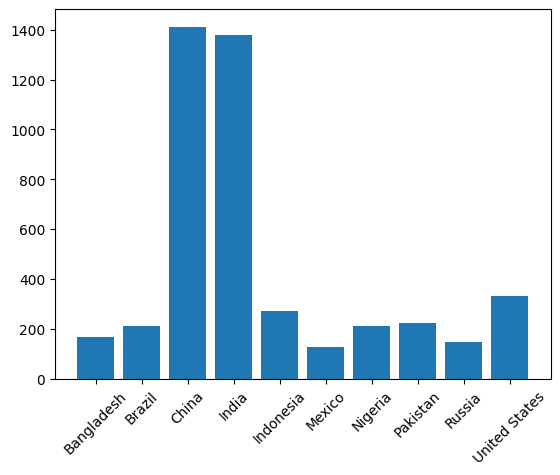

In [ ]:
# Function based
plt.bar(df.tara, height=df.populatie)
plt.xticks(rotation=45);

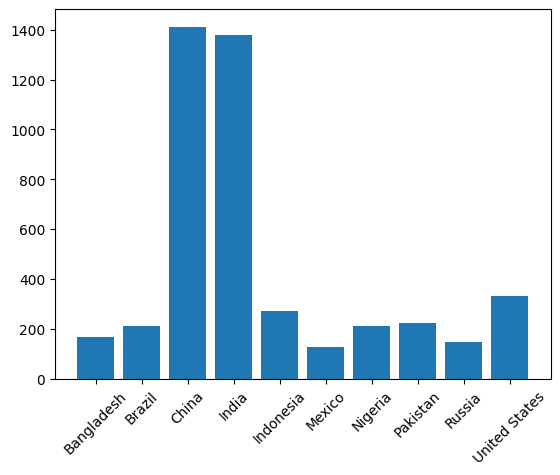

In [13]:
# OOP based
fig, axis = plt.subplots()
axis.bar(df.tara, height=df.populatie)
plt.xticks(rotation=45);

In [17]:

def update_function(frame):
    axis.clear()

    bars = axis.bar(df.tara, frame * np.arange(1, df.tara.size + 1))
    return bars


ani = animation.FuncAnimation(fig=fig, func=update_function, frames=40, interval=1500)
ani.save("test.mp4")
plt.show()

In [18]:
from IPython.display import HTML

def update_function(frame):
    axis.clear()

    bars = axis.bar(df.tara, frame * np.arange(1, df.tara.size + 1))
    return bars


ani = animation.FuncAnimation(fig=fig, func=update_function, frames=40, interval=1500)

plt.close()
HTML(ani.to_jshtml())


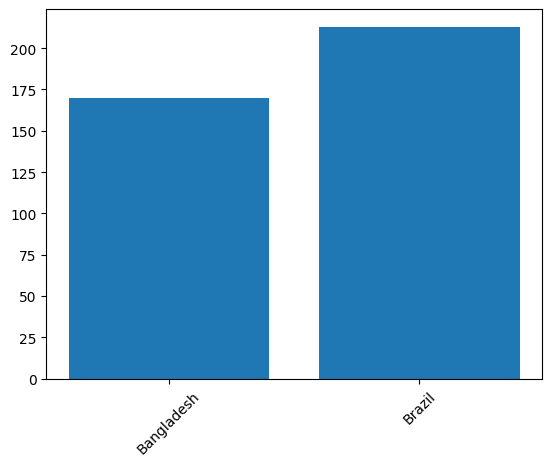

In [24]:
# OOP based
fig, axis = plt.subplots()
axis.bar(df.tara[:2], height=df.populatie[:2])
plt.xticks(rotation=45);

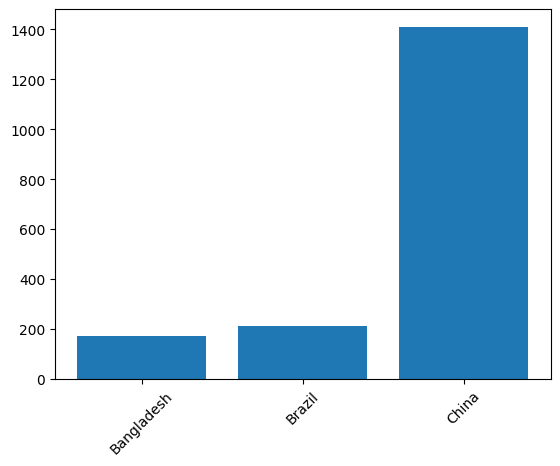

In [22]:
# OOP based
fig, axis = plt.subplots()
axis.bar(df.tara[:3], height=df.populatie[:3])
plt.xticks(rotation=45);

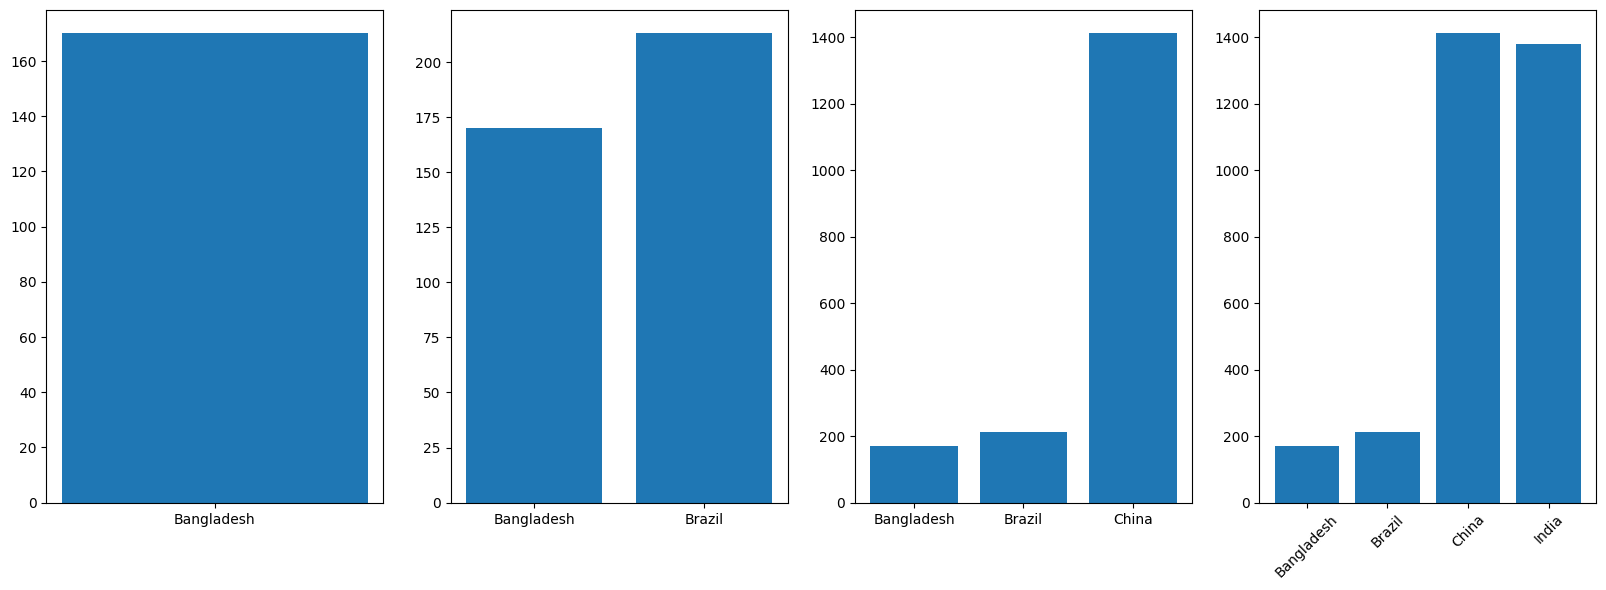

In [28]:
fig, axis = plt.subplots(ncols=4, figsize=(20, 6.4))

for i in range(4):  
    axis[i].bar(df.tara[:i + 1], height=df.populatie[: i + 1])

plt.xticks(rotation=45);

In [33]:
df = df.sort_index(ascending=False)
df

,tara,populatie
index,,
10,Mexico,126
9,Russia,146
8,Bangladesh,170
7,Nigeria,211
6,Brazil,213
5,Pakistan,225
4,Indonesia,271
3,United States,331
2,India,1378


In [34]:
df.index

Index([10, 9, 8, 7, 6, 5, 4, 3, 2, 1], dtype='int64', name='index')

In [44]:
fig, axis = plt.subplots()

def update_function(frame):
    axis.clear()
    bars = axis.bar(df.tara[:11-frame], df.populatie[:11-frame])
    axis.set_xticklabels(rotation=45, labels=df.tara[:11-frame])
    return bars


ani = animation.FuncAnimation(fig=fig, func=update_function, frames=df.index, interval=1500);

# ani.save("test.mp4")
# plt.show()

plt.close();
HTML(ani.to_jshtml())

/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/3482144879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(rotation=45, labels=df.tara[:11-frame])
/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/3482144879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(rotation=45, labels=df.tara[:11-frame])
/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/3482144879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(rotation=45, labels=df.tara[:11-frame])
/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/3482144879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

# Varianta 2 - bar horizontal dupa marimea populatiei

In [45]:
df.populatie.size

10

In [48]:
df.populatie[2]

np.int64(1378)

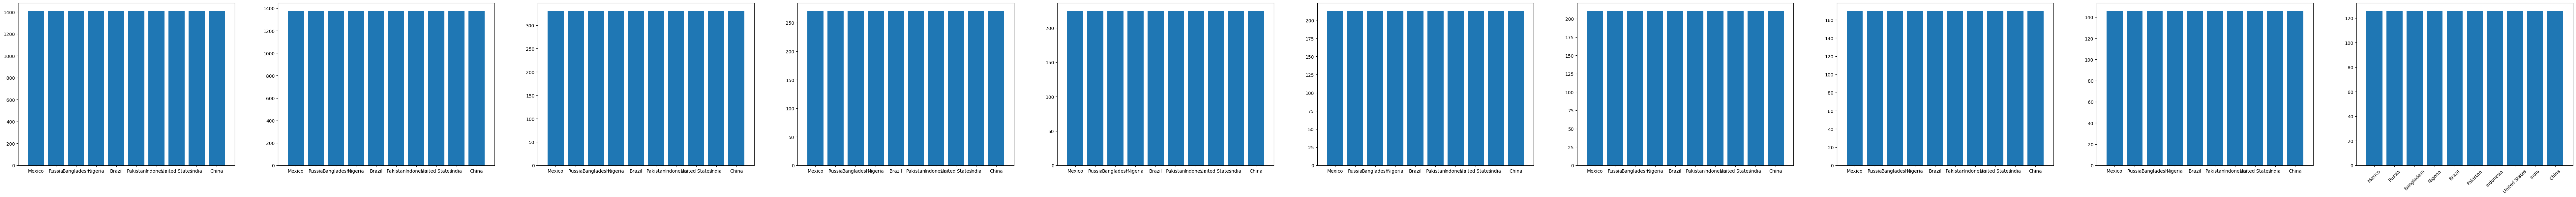

In [51]:
fig, axis = plt.subplots(ncols=df.populatie.size, figsize=(100, 6.4))

for i in range(df.populatie.size):  
    height =  np.ones(df.populatie.size)  * df.populatie[i+1]
    axis[i].bar(df.tara, height=height)

plt.xticks(rotation=45);

In [52]:
df.populatie

index
10     126
9      146
8      170
7      211
6      213
5      225
4      271
3      331
2     1378
1     1411
Name: populatie, dtype: int64

In [55]:
df

,tara,populatie
index,,
10,Mexico,126
9,Russia,146
8,Bangladesh,170
7,Nigeria,211
6,Brazil,213
5,Pakistan,225
4,Indonesia,271
3,United States,331
2,India,1378


In [57]:
for index, level in enumerate(df.populatie):
    print("index=", index, "level=", level)

index= 0 level= 126
index= 1 level= 146
index= 2 level= 170
index= 3 level= 211
index= 4 level= 213
index= 5 level= 225
index= 6 level= 271
index= 7 level= 331
index= 8 level= 1378
index= 9 level= 1411


In [59]:
dictionar_populatii = {
    level : [ list(df.populatie)[index] if list(df.populatie)[index] < level else level ] for index, level in enumerate(df.populatie)
}
dictionar_populatii

{126: [126],
 146: [146],
 170: [170],
 211: [211],
 213: [213],
 225: [225],
 271: [271],
 331: [331],
 1378: [1378],
 1411: [1411]}

In [60]:
dictionar_populatii = {
    level : [ inner_level if inner_level < level else level   for inner_level in df.populatie ] for index, level in enumerate(df.populatie)
}
dictionar_populatii

{126: [126, 126, 126, 126, 126, 126, 126, 126, 126, 126],
 146: [126, 146, 146, 146, 146, 146, 146, 146, 146, 146],
 170: [126, 146, 170, 170, 170, 170, 170, 170, 170, 170],
 211: [126, 146, 170, 211, 211, 211, 211, 211, 211, 211],
 213: [126, 146, 170, 211, 213, 213, 213, 213, 213, 213],
 225: [126, 146, 170, 211, 213, 225, 225, 225, 225, 225],
 271: [126, 146, 170, 211, 213, 225, 271, 271, 271, 271],
 331: [126, 146, 170, 211, 213, 225, 271, 331, 331, 331],
 1378: [126, 146, 170, 211, 213, 225, 271, 331, 1378, 1378],
 1411: [126, 146, 170, 211, 213, 225, 271, 331, 1378, 1411]}

In [66]:
fig, axis = plt.subplots()

axis.set_ylim(0, 1500)

def update_function(level):
    axis.clear()

    populations_at_level =  dictionar_populatii[level]

    bars = axis.bar(df.tara, populations_at_level)
    axis.set_ylim(0, 1500)
    axis.set_xticklabels(df.tara, rotation=45)
    return bars


ani = animation.FuncAnimation(fig=fig, func=update_function, frames=dictionar_populatii.keys(), interval=10000);

# ani.save("test.mp4")
# plt.show()

plt.close();
HTML(ani.to_jshtml())

/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/2280788499.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(df.tara, rotation=45)
/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/2280788499.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(df.tara, rotation=45)
/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/2280788499.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(df.tara, rotation=45)
/var/folders/3k/f_77v9pn1r94_xmvm2w3xgqr0000gn/T/ipykernel_4454/2280788499.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis.set_xticklabels(df